# Task - 1: Implementation of MCP Neurons:
1. Design a MCP Neuron for ”AND” Boolean Functions and ”OR” Boolean Functions with two
inputs:
Hint:
• Aggregate all the inputs.
• Handcraft a Threshold values for ”AND” and ”OR” Function.
• Implement a if else statement as stated above.

In [1]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This functions implements basic AND operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1 nd array): An array of binary values.
    X2 (1 nd array): An array of binary values.
    Output:
    state_neuron(1D-list): An state of neuron 1 or 0 for the particular inputs.
    """
    assert len(X1) == len(X2)
    state_neuron = []
    for i in range(len(X1)):
        # Perform an element wise addition of two input arrays
        sum_val = X1[i] + X2[i]
        # Append 1 if sum is above or equal to Threshold else append 0
        if sum_val >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)
    return state_neuron

# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T_and = 2 # Threshold value for AND
result_and = MCP_Neurons_AND(X1, X2, T_and)
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T_and}: {result_and}")

def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    state_neuron = []
    for i in range(len(X1)):
        # Perform an element wise addition
        sum_val = X1[i] + X2[i]
        # Append 1 if sum is above or equal to Threshold else append 0
        if sum_val >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)
    return state_neuron

# Example usage for MCP_Neurons_OR function
T_or = 1 # Threshold value for OR
result_or = MCP_Neurons_OR(X1, X2, T_or)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T_or}: {result_or}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]
Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


## Answer the Following Question:

**Question - 1: List out all the limitations of MCP - Neurons.**

*   **Fixed Parameters:** Weights and thresholds are handcrafted and fixed; the model cannot learn from data.
*   **Linear Separability:** MCP Neurons can only solve problems where the classes can be separated by a straight line (linearly separable). They cannot solve non-linear problems like XOR.
*   **Binary Values Only:** They are restricted to binary inputs and outputs (0 and 1), meaning they cannot handle continuous or real-valued data.
*   **No Training Algorithm:** There is no optimization process (like gradient descent) to update parameters based on errors.

**Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.**

A single MCP neuron cannot solve the XOR function because it is not linearly separable. However, XOR can be solved using a multi-layer arrangement of MCP neurons by combining other gates:
*   **Logic:** `XOR(x1, x2) = AND(OR(x1, x2), NOT(AND(x1, x2)))`
*   **If-else rule logic:**
    ```python
    if (x1 + x2) == 1:
        return 1
    else:
        return 0
    ```
    *Note: While the if-else code above works, it represents a specific non-linear condition that a single standard sum-and-threshold MCP neuron cannot achieve without multiple steps or layers.*

# Task 2: Perceptron Algorithm for 0 vs 1 Classification.
1. Objective:
In this exercise, you will implement a Perceptron learning algorithm for binary classification using the
MNIST dataset. Specifically, you will classify the digits 0 and 1. After completing the Perceptron
algorithm, you will evaluate the model’s performance and visualize misclassified images.
Dataset: mnist_0_and_1.csv

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


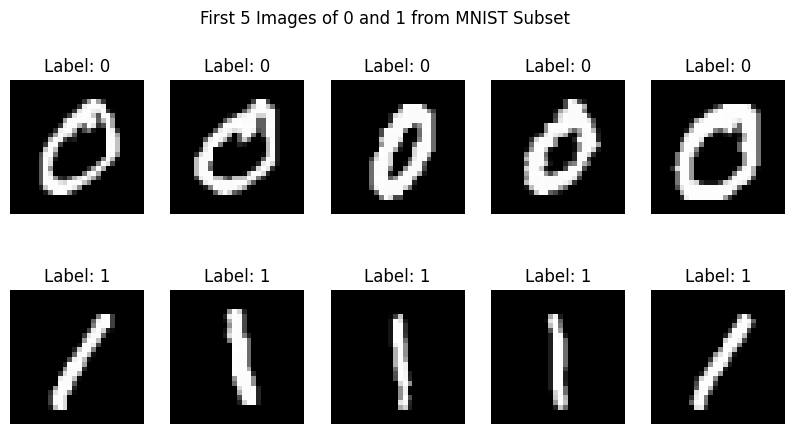

The Final Accuracy is:  0.9992104224240032


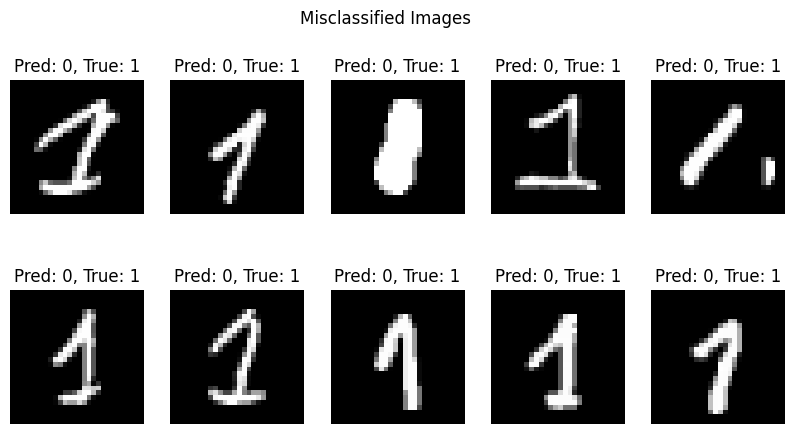

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Load the Dataset
df_0_1 = pd.read_csv("/content/mnist_0_and_1.csv")
X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

# Visualize the Dataset
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

# 3. Initialize Weights and Bias
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 10

# 4. Implement Decision Function
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

# 5. Implement Perceptron Learning Algorithm
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=10):
    n_samples = X.shape[0]
    for epoch in range(epochs):
        errors = 0
        for i in range(n_samples):
            linear_output = np.dot(X[i], weights) + bias
            y_predicted = 1 if linear_output >= 0 else 0

            if y_predicted != y[i]:
                update = learning_rate * (y[i] - y_predicted)
                weights += update * X[i]
                bias += update
                errors += 1

        # Optional: Print progress
        # print(f"Epoch {epoch+1}, Errors: {errors}")
        if errors == 0:
            break

    y_pred_final = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred_final == y)
    return weights, bias, accuracy

# 6. Putting it all Together
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)
print("The Final Accuracy is: ", accuracy)

# 7. Visualizing the Misclassified Image
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    num_to_show = min(10, len(misclassified_idx))
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:num_to_show]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

## Task 2: Perceptron Algorithm - Questions and Answers

**Question - 1 & 2: What does the shape of X represent?**
The shape `(12665, 784)` means there are 12,665 images in the dataset, and each image consists of 784 pixels (representing a flattened 28x28 image).

**Question - 3: What does the weights array represent in this context?**
The weights represent the learned importance of each pixel. A positive weight for a specific pixel increases the likelihood of the model predicting a '1', while a negative weight pushes the prediction towards '0'.

**Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?**
Initializing to zero provides a neutral starting point. In a Perceptron, weights will only change when a mistake is made. Since the update is driven by the pixel values of misclassified images, the weights will quickly diverge from zero to form a decision boundary.

**Question - 5: What is the purpose of the `output = np.dot(X[i], weights) + bias` line?**
This line calculates the weighted sum of all inputs. It represents the evidence for a particular class. The sign of this output determines the final binary prediction.

**Question - 6: What happens when the prediction is wrong? How are the weights and bias updated?**
If the prediction is wrong, the weights are adjusted using the formula: `weights = weights + learning_rate * (target - prediction) * input`. This shifts the weights in a direction that reduces the error for that specific input in the future.

**Question - 7: Why is the final accuracy important, and what do you expect it to be?**
Accuracy tells us how well the model has learned to distinguish between 0 and 1. Since these two digits are largely linearly separable in MNIST, we expect a very high accuracy (close to 99-100%).

**Question - 8: What does `misclassified_idx` store, and how is it used in this code?**
It stores the indices of the images that the model predicted incorrectly. The code uses these indices to retrieve and display the actual images so we can visually inspect why the model might have failed.

**Question - 9: How do you interpret the result if the output is "All images were correctly classified!"?**
This indicates that the Perceptron has successfully found a linear hyperplane that perfectly separates the two classes (0s and 1s) in the given dataset.

# Task 3: Perceptron Algorithm for 3 vs 5 Classification.
1. Objective:
In this exercise, you will implement a Perceptron learning algorithm for binary classification using the
MNIST dataset. Specifically, you will classify the digits 3 and 5. After completing the Perceptron
algorithm, you will evaluate the model’s performance and visualize misclassified images.
Dataset: mnist_3_and_5.csv

Feature matrix shape: (2741, 784)
Original Label distribution: (array([3, 5]), array([1484, 1257]))
Final Accuracy for 3 vs 5: 0.9540


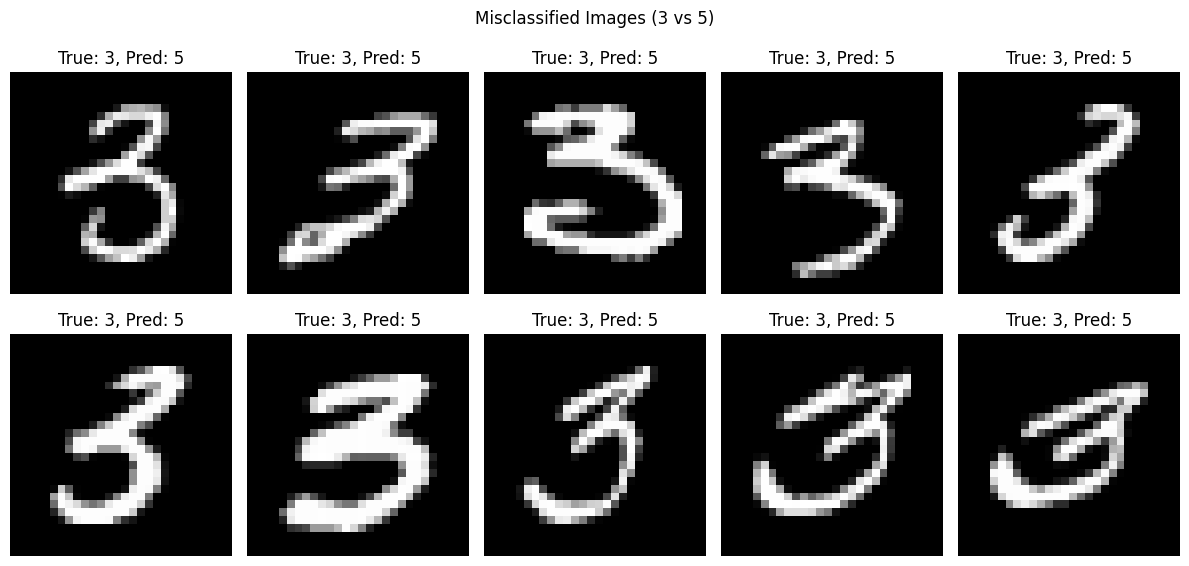


Conclusion:
The Perceptron performed well, but the accuracy is likely lower than the 0 vs 1 task.
This is because digits 3 and 5 share more overlapping visual features (like the top horizontal bar and middle curve),
making them less 'linearly separable' than digits 0 and 1.


In [3]:
# 1. Load the Dataset for 3 and 5
df_3_5 = pd.read_csv('/content/mnist_3_and_5.csv')
X_35 = df_3_5.drop(columns=['label']).values
y_35 = df_3_5['label'].values

# Map labels to 0 and 1 for binary classification (3 -> 0, 5 -> 1)
# This is necessary because the Perceptron algorithm expects binary targets
y_35_mapped = np.where(y_35 == 3, 0, 1)

print(f"Feature matrix shape: {X_35.shape}")
print(f"Original Label distribution: {np.unique(y_35, return_counts=True)}")

# 2. Initialize Weights and Bias
weights_35 = np.zeros(X_35.shape[1])
bias_35 = 0
learning_rate = 0.1
epochs = 20 # Increased epochs slightly as 3 vs 5 is harder than 0 vs 1

# 3. Train the Perceptron
# Reusing the train_perceptron function defined earlier
weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35_mapped, weights_35, bias_35, learning_rate, epochs
)

print(f"Final Accuracy for 3 vs 5: {accuracy_35:.4f}")

# 4. Visualize Misclassified Images
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)
misclassified_idx_35 = np.where(y_pred_35 != y_35_mapped)[0]

if len(misclassified_idx_35) > 0:
    num_show = min(10, len(misclassified_idx_35))
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    for i, idx in enumerate(misclassified_idx_35[:num_show]):
        ax = axes.flat[i]
        ax.imshow(X_35[idx].reshape(28, 28), cmap='gray')
        actual_digit = 3 if y_35_mapped[idx] == 0 else 5
        pred_digit = 3 if y_pred_35[idx] == 0 else 5
        ax.set_title(f"True: {actual_digit}, Pred: {pred_digit}")
        ax.axis('off')
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

# Conclusion
print("\nConclusion:")
print("The Perceptron performed well, but the accuracy is likely lower than the 0 vs 1 task.")
print("This is because digits 3 and 5 share more overlapping visual features (like the top horizontal bar and middle curve),")
print("making them less 'linearly separable' than digits 0 and 1.")